In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
import pandas as pd
import numpy as np

In [3]:
sys.path.append(os.path.abspath("../src"))

In [4]:
from data_loader import load_features
from preprocessing import (basic_preprocess, scale_data, apply_pca, remove_outliers)

In [5]:
features = load_features("../data/fma_metadata/fma_metadata/features.csv")

In [6]:
print(features.isna().any().sum())
#izbaci rad sa nan vrednostima iz druge sveske

0


In [7]:
features = basic_preprocess(features)

In [8]:
features = scale_data(features)

In [9]:
x_pca25 = apply_pca(features, 25)
x_pca60 = apply_pca(features, 60)
x_pca90_prec = apply_pca(features, 0.9)

In [10]:
X_cleared_pca25 = remove_outliers(x_pca25, contamination=0.02)
X_cleared_pca60 = remove_outliers(x_pca60, contamination=0.02)
X_cleared_pca90_prec = remove_outliers(x_pca90_prec, contamination=0.02)

In [11]:
X_sample_pca25 = X_cleared_pca25.sample(n=10000, random_state=42)
X_sample_pca60 = X_cleared_pca60.sample(n=10000, random_state=42)
X_sample_pca90 = X_cleared_pca90_prec.sample(n=10000, random_state=42)

## GMM

In [12]:
from tuning import tune_gmm

In [13]:
results_25 = tune_gmm(X_sample_pca25)
results_60 = tune_gmm(X_sample_pca60)
results_90_prec = tune_gmm(X_sample_pca90)

In [14]:
df25 = pd.DataFrame(results_25)
df25["pca"] = 25
df60 = pd.DataFrame(results_60)
df60["pca"] = 60
df90 = pd.DataFrame(results_90_prec)
df90["pca"] = 90

In [15]:
results = pd.concat([df25, df60, df90], ignore_index=True)

In [16]:
df = pd.DataFrame(results)
df_sorted = df.sort_values("bic")
df_sorted.head()

,components,covariance_type,bic,aic,pca
15,8,full,981326.556181,961087.130757,25
12,7,full,981772.296053,964063.700100,25
18,9,full,982404.851132,959634.596237,25
9,6,full,982441.432020,967263.665537,25
21,10,full,983083.600330,957782.515964,25


In [17]:
best_per_pca = results.loc[results.groupby("pca")["bic"].idxmin()]
print(best_per_pca)

     components covariance_type           bic           aic  pca
15            8            full  9.813266e+05  9.610871e+05   25
57            5            full  1.815348e+06  1.747182e+06   60
105           4            full  3.265599e+06  2.903330e+06   90


In [4]:
import matplotlib.pyplot as plt

In [19]:
df25 = results[results["pca"] == 25]
df60 = results[results["pca"] == 60]
df90 = results[results["pca"] == 90]

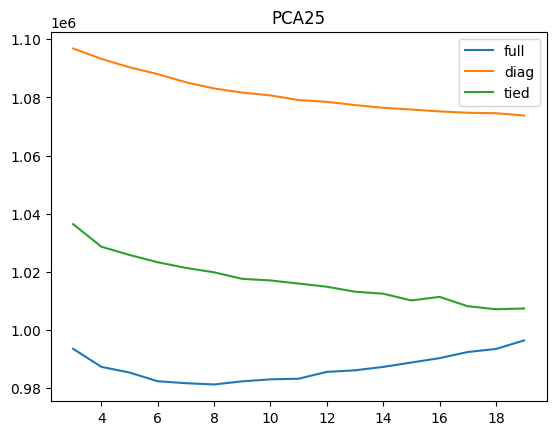

In [20]:
for cov in df25['covariance_type'].unique():
    subset = df25[df25['covariance_type'] == cov]
    subset = subset.sort_values("components")

    plt.plot(subset['components'], subset['bic'], label=cov)

plt.legend()
plt.title("PCA25")
plt.show()

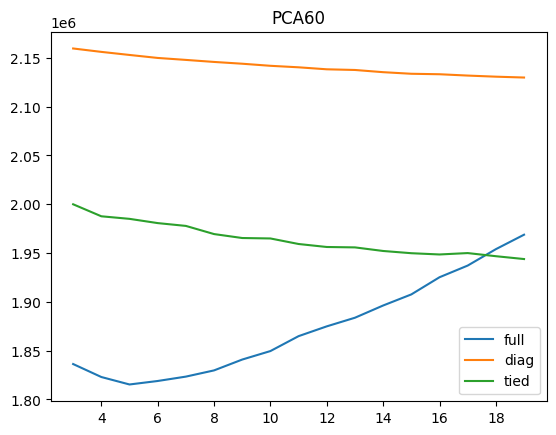

In [21]:
for cov in df60['covariance_type'].unique():
    subset = df60[df60['covariance_type'] == cov]
    subset = subset.sort_values("components")

    plt.plot(subset['components'], subset['bic'], label=cov)

plt.legend()
plt.title("PCA60")
plt.show()

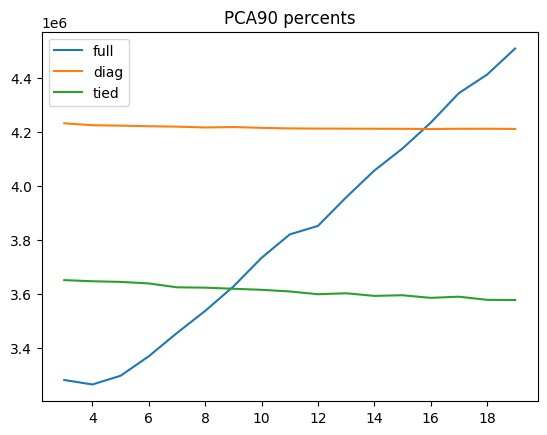

In [22]:
for cov in df90['covariance_type'].unique():
    subset = df90[df90['covariance_type'] == cov]
    subset = subset.sort_values("components")

    plt.plot(subset['components'], subset['bic'], label=cov)

plt.legend()
plt.title("PCA90 percents")
plt.show()

# lowest bic: PCA25 + 8 components + full

## HDBSCAN

HDBSCAN je algoritam za klasterovanje zasnovan na gustini, koji ne zahteva unapred zadat broj klastera i može da detektuje šum (outlier-e).

Za razliku od GMM modela, evaluacija je izvršena korišćenjem density-based kriterijuma (DBCV), implementiranog kroz `relative_validity_`.

Zbog toga što HDBSCAN može označiti veliki deo podataka kao šum, dodatno je uvedena penalizacija na osnovu udela noise tačaka.

In [45]:
from tuning import tune_hdbscan

In [46]:
results_hdb_25 = tune_hdbscan(X_sample_pca25)
results_hdb_60 = tune_hdbscan(X_sample_pca60)
results_hdb_90 = tune_hdbscan(X_sample_pca90)

In [47]:
df25 = pd.DataFrame(results_hdb_25)
df25["pca"] = 25
df60 = pd.DataFrame(results_hdb_60)
df60["pca"] = 60
df90 = pd.DataFrame(results_hdb_90)
df90["pca"] = 90

In [48]:
results_hdb = pd.concat([df25, df60, df90], ignore_index=True)

In [49]:
results_hdb.sort_values("adjusted_score", ascending=False).head()

,min_cluster_size,min_samples,dbcv,adjusted_score,n_clusters,noise_ratio,pca
67,50,9,-1,-0.0,0,1.0,25
66,50,7,-1,-0.0,0,1.0,25
68,50,11,-1,-0.0,0,1.0,25
69,50,13,-1,-0.0,0,1.0,25
53,40,9,-1,-0.0,0,1.0,25


In [50]:
best_hdb = results_hdb.sort_values("adjusted_score", ascending=False).iloc[0]
print(best_hdb)

min_cluster_size    50.0
min_samples          9.0
dbcv                -1.0
adjusted_score      -0.0
n_clusters           0.0
noise_ratio          1.0
pca                 25.0
Name: 67, dtype: float64


In [3]:
import seaborn as sns

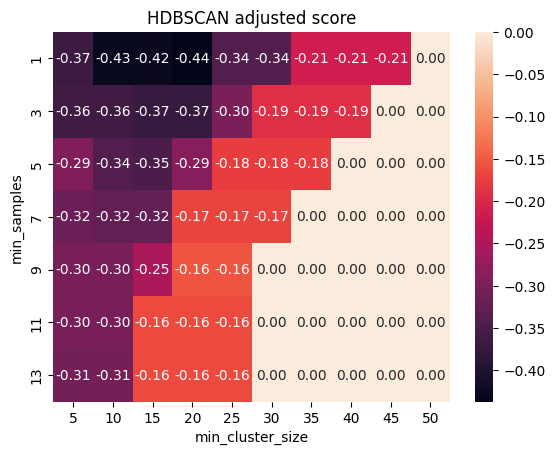

In [52]:
pivot = results_hdb.pivot_table(index="min_samples", columns="min_cluster_size", values="adjusted_score", aggfunc="mean")

sns.heatmap(pivot, annot=True, fmt=".2f")
plt.title("HDBSCAN adjusted score")
plt.show()

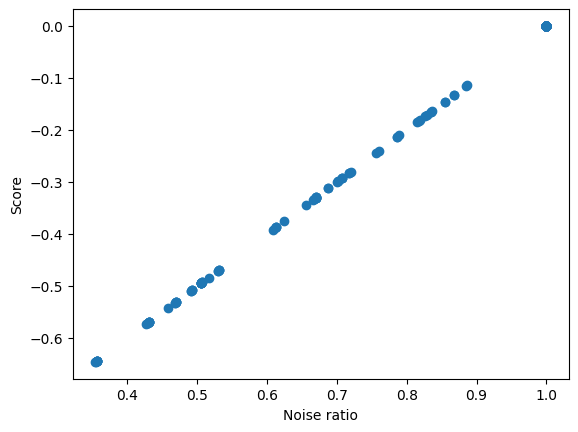

In [53]:
plt.scatter(results_hdb["noise_ratio"], results_hdb["adjusted_score"])
plt.xlabel("Noise ratio")
plt.ylabel("Score")
plt.show()

Sa slike vidimo da sto vise HDBSCAN ignorise podatke to mu je score bolji. HDBSCAN favorizuje kompaktne i guste klastere, ali po cenu odbacivanja velikog dela podataka.
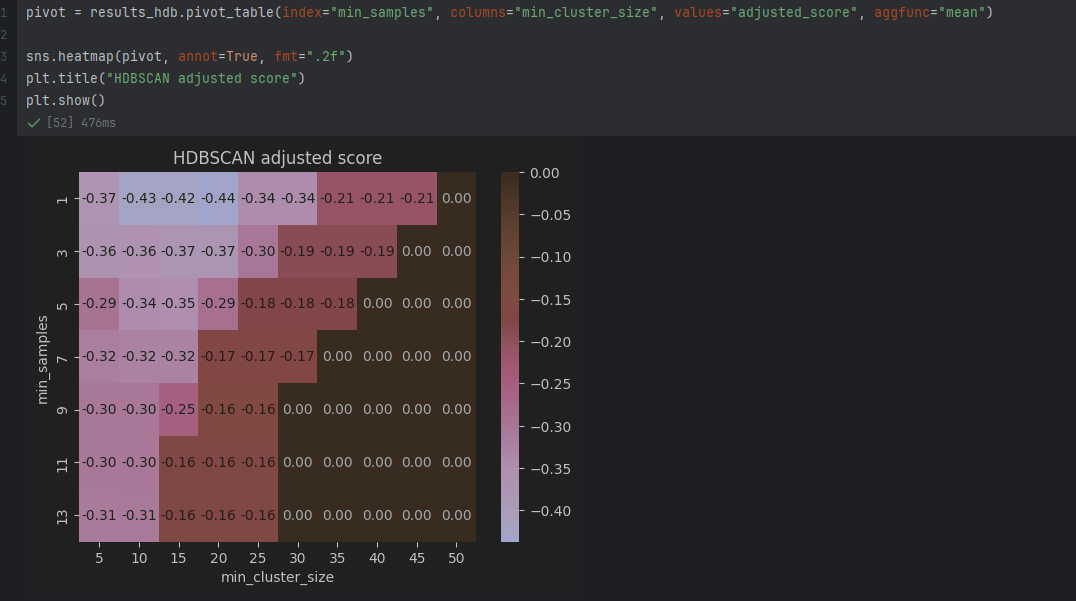

In [56]:
df = results_hdb[
    (results_hdb["noise_ratio"] < 0.6) &
    (results_hdb["n_clusters"] >= 2)
]
df.head()

,min_cluster_size,min_samples,dbcv,adjusted_score,n_clusters,noise_ratio,pca
0,5,1,-1,-0.5420,27,0.4580,25
1,5,3,-1,-0.5729,9,0.4271,25
3,5,7,-1,-0.4839,4,0.5161,25
4,5,9,-1,-0.4706,3,0.5294,25
5,5,11,-1,-0.4940,3,0.5060,25


## OPTICS

In [14]:
from tuning import tune_optics

In [15]:
results_optics_25 = tune_optics(X_sample_pca25)
results_optics_60 = tune_optics(X_sample_pca60)
#results_optics_90 = tune_optics(X_sample_pca90)

time: 27.61989712715149
time: 24.655067443847656
time: 24.121492385864258
time: 24.361849308013916
time: 24.068630933761597
time: 23.94596290588379
time: 24.386780261993408
time: 23.651145696640015
time: 24.247156381607056
time: 23.86916756629944
time: 23.87016463279724
time: 24.185322046279907
time: 24.22721004486084
time: 24.191307306289673
time: 23.522111654281616
time: 23.776413202285767
time: 23.871161699295044
time: 23.7125883102417
time: 24.293035745620728
time: 23.51212239265442
time: 23.888088941574097
time: 24.06663966178894
time: 23.54802441596985
time: 24.06364607810974
time: 23.452281951904297
time: 23.93997573852539
time: 24.130470275878906
time: 23.764464139938354
time: 24.182329654693604
time: 23.625816822052002
time: 23.942970037460327
time: 24.53638243675232
time: 23.761455535888672
time: 24.094563007354736
time: 23.421363830566406
time: 24.00380849838257
time: 23.96092176437378
time: 23.687652349472046
time: 24.279069423675537
time: 23.60042428970337
time: 23.6667077

In [16]:
df25 = pd.DataFrame(results_optics_25)
df25["pca"] = 25
df60 = pd.DataFrame(results_optics_60)
df60["pca"] = 60
#df90 = pd.DataFrame(results_optics_90)
#df90["pca"] = 90

In [17]:
results_optics = pd.concat([df25, df60], ignore_index=True)

In [18]:
results_optics.sort_values("adjusted_score", ascending=False).head()

,min_samples,xi,min_cluster_size,silhouette,adjusted_score,n_clusters,noise_ratio,pca
0,3,0.03,4,0.303220,0.010340,70,0.9659,25
32,5,0.03,4,0.361308,0.006901,34,0.9809,25
8,3,0.05,4,0.471257,0.006880,27,0.9854,25
16,3,0.07,4,0.613438,0.006502,16,0.9894,25
224,3,0.03,4,0.385492,0.006206,29,0.9839,60


In [19]:
df = results_optics[
    (results_optics["n_clusters"] >= 2) &
    (results_optics["noise_ratio"] < 0.6)
]
df.head()

,min_samples,xi,min_cluster_size,silhouette,adjusted_score,n_clusters,noise_ratio,pca


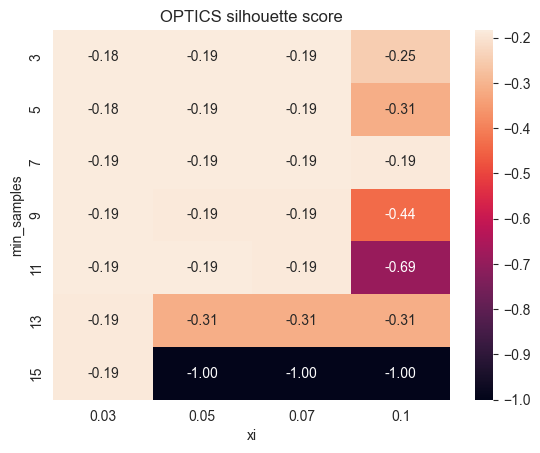

In [24]:
pivot = results_optics.pivot_table(index="min_samples",columns="xi", values="adjusted_score",aggfunc="mean")

sns.heatmap(pivot, annot=True, fmt=".2f")
plt.title("OPTICS silhouette score")
plt.show()

In [12]:
from tuning import tune_agglomerative

In [13]:
results_agglom_25 = tune_agglomerative(X_sample_pca25)
results_agglom_60 = tune_agglomerative(X_sample_pca60)
results_agglom_90 = tune_agglomerative(X_sample_pca90)
#todo

KeyboardInterrupt: 

In [ ]:
df25 = pd.DataFrame(results_agglom_25)
df25["pca"] = 25
df60 = pd.DataFrame(results_agglom_60)
df60["pca"] = 60
df90 = pd.DataFrame(results_agglom_90)
df90["pca"] = 90

In [ ]:
results_agglom = pd.concat([df25, df60, df90], ignore_index=True)

In [ ]:
results_agglom.sort_values("sillhuete", ascending=False).head()

In [ ]:
pivot = df.pivot_table(index="n_clusters", columns="linkage", values="silhouette", aggfunc="mean")

In [ ]:
pivot = results_agglom.pivot_table(index="n_clusters",columns="linkage", values="silhuette",aggfunc="mean")

sns.heatmap(pivot, annot=True, fmt=".2f")
plt.title("AgllomerativeClustering silhouette score")
plt.show()